In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt

columns = ["target", "id", "date", "flag", "user", "text"]

df = pd.read_csv("training.1600000.processed.noemoticon.csv",encoding="latin-1",names=columns)

df = df[["target","text"]]
df.head()


,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [3]:
negative = df[df["target"]==0].sample(n=100000, random_state = 42)
positive = df[df["target"]==4].sample(n=100000,random_state=42)

data = pd.concat([positive,negative])
data = data.sample(frac=1,random_state=42).reset_index(drop=True) # suffle the order frac 1 means 100% of the data. reset_index(drop=true) resets the indexes 

data["target"] = data["target"].map({0:0,4:1})
data.head()

,target,text
0,0,@souljaboytellem drop me a dm. i might not be ...
1,1,@swalkingtree hi sequoia be well!
2,0,"Nvm, they come off June 9."
3,1,"@ElePhatt LOL thanks you, nice meeting you a..."
4,1,is at SL Training Week and was just officially...


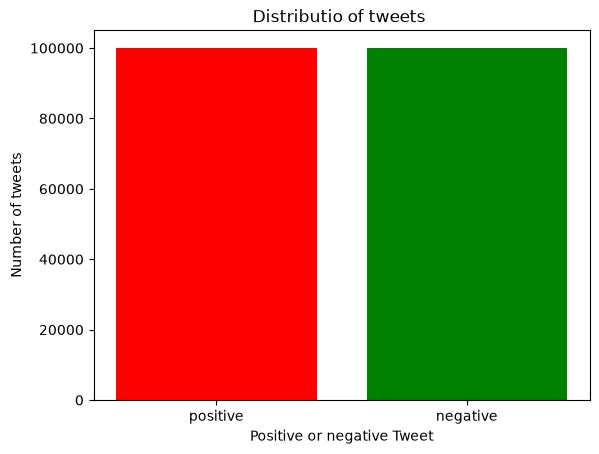

In [4]:
counts = data["target"].value_counts() # .value_count() returns a series containing frequency of each occurance

plt.bar(['positive','negative'],counts.values,color=["red","green"])
plt.title("Distributio of tweets ")
plt.xlabel('Positive or negative Tweet')
plt.ylabel("Number of tweets")
plt.savefig("images/class_balance.png", dpi=150, bbox_inches="tight")
plt.show()


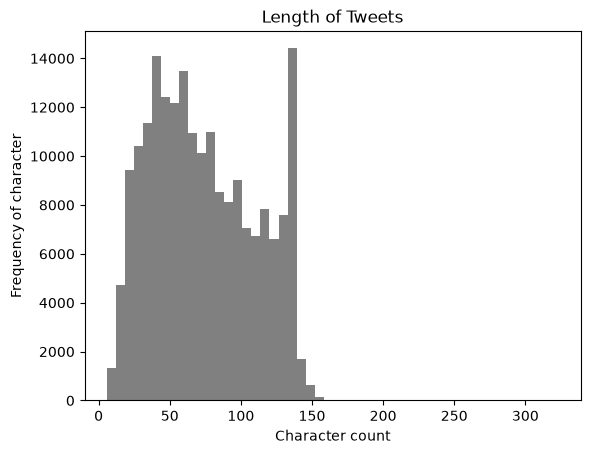

,target,text,length
0,0,@souljaboytellem drop me a dm. i might not be ...,67
1,1,@swalkingtree hi sequoia be well!,34
2,0,"Nvm, they come off June 9.",27
3,1,"@ElePhatt LOL thanks you, nice meeting you a...",91
4,1,is at SL Training Week and was just officially...,91


In [5]:
data["length"] = data["text"].apply(len) # .apply() method apply the len function on each row of the data

plt.hist(data['length'],bins=50,color='grey')
plt.title("Length of Tweets")
plt.xlabel("Character count")
plt.ylabel("Frequency of character")
plt.savefig("images/tweet_length.png", dpi=150, bbox_inches="tight")
plt.show()
plt.show()
data.head()

In [6]:
import re

def clean_tweet(text:str)->str:
    """ Removes any url, @-mention, #-hastags, puncutautions, Upper case, space more than one """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+","",text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["clean_text"] = data["text"].apply(clean_tweet)
data[["text","clean_text"]].head()

,text,clean_text
0,@souljaboytellem drop me a dm. i might not be ...,drop me a dm i might not be on at work boy holla
1,@swalkingtree hi sequoia be well!,hi sequoia be well
2,"Nvm, they come off June 9.",nvm they come off june
3,"@ElePhatt LOL thanks you, nice meeting you a...",lol thanks you nice meeting you aswell looking...
4,is at SL Training Week and was just officially...,is at sl training week and was just officially...


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


X_train, X_test, Y_train, Y_test = train_test_split(
    data['clean_text'],data['target'],test_size = 0.2 , random_state=42
)

vectorizer = TfidfVectorizer(max_features = 5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Logistic Regression Accuracy 0.78215


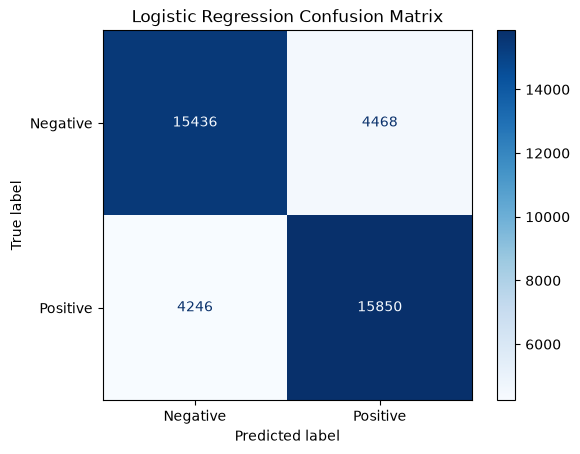

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_tfidf,Y_train)

log_prediction = log_model.predict(X_test_tfidf)

log_accuracy = accuracy_score(Y_test,log_prediction)
print("Logistic Regression Accuracy",log_accuracy)

cm = confusion_matrix(Y_test, log_prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.savefig("images/confusion_logistic.png", dpi=150, bbox_inches="tight")
plt.show()


Naive bayes algroithm accuracy score: 0.761625


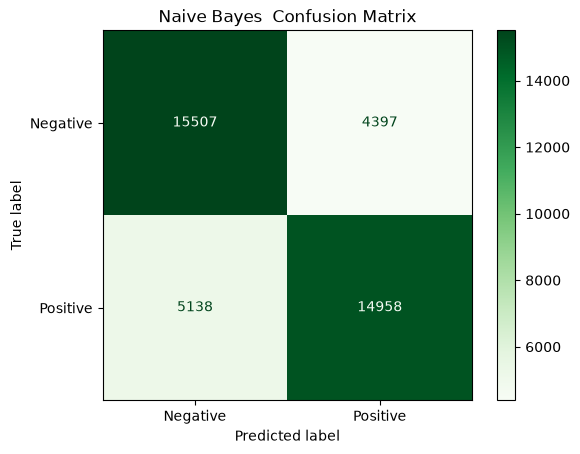

In [9]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf,Y_train)

nb_prediction = nb_model.predict(X_test_tfidf)

nb_accuracy = accuracy_score(Y_test,nb_prediction)
print("Naive bayes algroithm accuracy score:" ,nb_accuracy)

cm_nb = confusion_matrix(Y_test,nb_prediction)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=["Negative", "Positive"])
disp_nb.plot(cmap="Greens")
plt.title("Naive Bayes  Confusion Matrix")
plt.savefig("images/confusion_naive_bayes.png", dpi=150, bbox_inches="tight")

plt.show()


Linear SVM accuracy scores:  0.7789


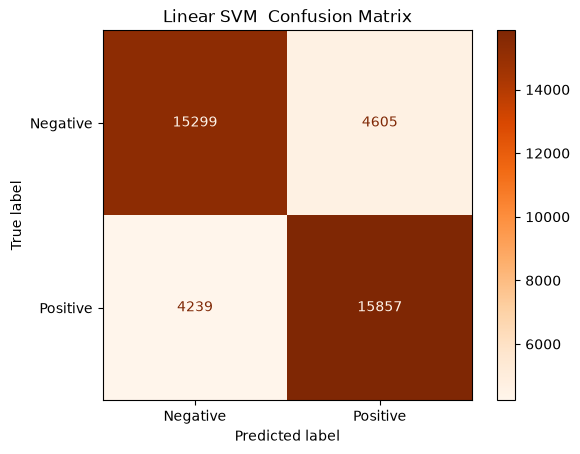

In [11]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, Y_train)

svm_predict = svm_model.predict(X_test_tfidf)

svm_accuracy = accuracy_score(Y_test,svm_predict)
print("Linear SVM accuracy scores: ", svm_accuracy)

cm_svm = confusion_matrix(Y_test, svm_predict)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=["Negative", "Positive"])
disp_svm.plot(cmap="Oranges")
plt.title("Linear SVM  Confusion Matrix")
plt.savefig("images/confusion_svm.png", dpi=150, bbox_inches="tight")

plt.show()

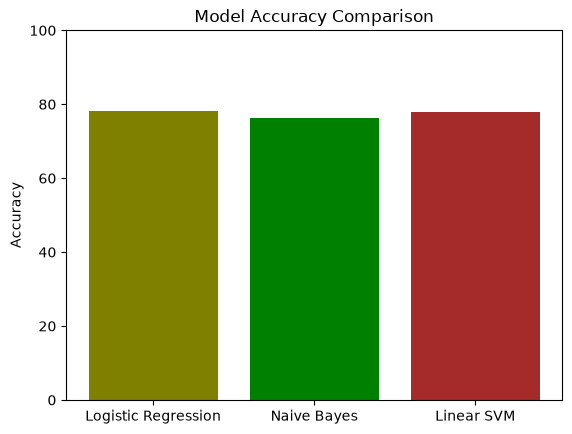

In [13]:
model_names = ["Logistic Regression", "Naive Bayes", "Linear SVM"]
accuracies = [log_accuracy*100, nb_accuracy*100, svm_accuracy*100]

plt.bar(model_names, accuracies, color=["olive", "green", "brown"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 100)
plt.savefig("images/comparison_chart.png", dpi=150, bbox_inches="tight")
plt.show()


In [28]:
import pickle

with open("log_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

with open("nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)

with open("svm_model.pkl", "wb") as f:
    pickle.dump(svm_model, f)

with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)